<font size="16"> Performance analysis </font>

# Imports

In [2]:
import sys, os, h5py, bz2, pylab as plt, importlib, itertools
from tqdm.auto import tqdm, trange
from collections import OrderedDict
import seaborn
from ipywidgets import interactive, fixed
plt.style.use('dark_background')
# plt.style.use('default')
%pylab inline
%load_ext autoreload
%autoreload 2
if 'notebooks' in os.getcwd(): os.chdir('..')
print(os.getcwd())
import matplotlib as mpl
mpl.rcParams.update({"axes.grid" : False})
mpl.rcParams['axes.axisbelow'] = True
mpl.rcParams['grid.linestyle'] = '--'
import datetime
import pandas as pd
import glob





%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/home2/tomaszk/miniforge3/envs/datascience/lib/python3.11/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['plt', 'interactive']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


/mnt/nas05/data01/cluster-user-homes/tomaszk/251202_cosmogridv1_de/012_pixi_benchmarks


# Functions

In [3]:
def load_timing(fname):
    df = pd.read_csv(fname, sep=' ', names=['Step', 'Gravity', 'IO', 'Tree', 'DomainDecom', 'KickOpen', 'KickClose',  'heh?', 'wtf?', 'whatever col?',  'bah humbug?', 'Density', 'EndTimeStep', 'Gradient', 'Flux', 'TimeStep', 'Drift', 'FoF', 'Others'], skiprows=1)
    t = df.to_records()
    return t

In [4]:
def plot_timing(t, title='', ylim=(0, 8)):

  

    # Get column names, skipping the first one ('Step')
    col_names = t.dtype.names
    x = t['Step']
    colors = seaborn.color_palette('tab20', len(col_names))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    # First panel: absolute values
    for i, name in enumerate(col_names):
        if (name != 'Step') and (name != 'index'):
            axes[0].plot(x, t[name]/60, label=name, marker='o', color=colors[i])

    # Add a series that is the sum of all columns (except 'Step') for each step
    total = np.array([t[name] for name in col_names if ((name != 'Step') and (name != 'index'))])
    total = np.sum(total, axis=0)
    axes[0].plot(x, total/60, label='Total', marker='o', linewidth=5, color='hotpink')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Time [min]')
    axes[0].set_title('Timing Breakdown by Step')
    axes[0].legend(frameon=False, ncol=2, loc='upper left')
    axes[0].set_ylim(ylim)

    # Second panel: normalized by total
    for i, name in enumerate(col_names):
        if (name != 'Step') and (name != 'index'):
            # Avoid division by zero
            norm = t[name] / total if np.all(total != 0) else np.zeros_like(total)
            axes[1].plot(x, norm, label=name, marker='o', color=colors[i])

    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Fraction of Total')
    axes[1].set_title('Normalized Timing Breakdown')
    axes[1].legend(frameon=False, ncol=2, loc='upper left')
    axes[1].set_yscale('log')
    axes[1].set_ylim(1e-4, 1)

    plt.tight_layout()

    grand_total = 0
    for name in col_names:
        if (name != 'Step') and (name != 'index'):
            grand_total += np.sum(t[name])

    

    info_str = 'num steps {:4d}, grand total {:2.2f} hours'.format(len(t), grand_total/60/60)

    plt.suptitle(title + '\n' + info_str, y=1.1)  # Move suptitle down a bit to add padding below



In [5]:
def compare_cases(list_cases, max_step=40, ylim=(None, None)):

    t_cases = []
    for case in list_cases:
        t = load_timing(f'{case}/pkdgrav3_benchmark.timing')
        t_cases.append(t)
        # max_step = min(max_step, len(t))

    col_names = t.dtype.names
    t_total = []
    t_total_per_step = np.zeros((len(t_cases), max_step))
    for i in range(len(t_cases)):
        grand_total = 0
        for name in col_names:
            if (name != 'Step') and (name != 'index'):
                grand_total += np.sum(t_cases[i][name][:max_step])
        
                for j in range(max_step):
                    a = t_cases[i][name][j]
                    t_total_per_step[i, j] += a

        t_total.append(grand_total)
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    colors = seaborn.color_palette('tab20', len(t_cases))
    for i, (label, case) in enumerate(zip(list_cases, t_cases)):
        tag = f'{label} {specs[label]} {t_total[i]/60/60:.2f} hours'
        axes[0].plot(t_total_per_step[i]/60, label=tag, marker='o', color=colors[i])
        ref = np.cumsum(t_total_per_step[0]/60)
        new = np.cumsum(t_total_per_step[i]/60)
        axes[1].plot(new/ref-1, label=tag, marker='o', color=colors[i])

    axes[0].legend(frameon=False, ncol=1, loc='upper left')
    axes[1].legend(frameon=False, ncol=1, loc='upper left')

    axes[0].set_xlabel('Step')
    axes[0].set_ylim(ylim)
    axes[1].set_xlabel('Step')
    axes[0].set_ylabel('Time per step [min]')
    axes[1].set_ylabel('Cumulative time relative to Case1')

    plt.tight_layout()
    plt.show()   

# nGrid

In [6]:
specs = {'01_ngrid1024': 'nGrid=1024 GPU',
         '02_ngrid1024_nogpu': 'nGrid=1024 NO GPU',
         '03_ngrid1536': 'nGrid=1536 NO GPU',
         } 


BENCHMARK: 01_ngrid1024


Slurm statistics for 241983.0
State:                         COMPLETED
Wall time:                     4.934 h

CPU
------------------------------------------------------------
CPU time actually consumed:    454.513 CPU-hours
Allocated CPUs:                96
CPU capacity allocated:        473.680 CPU-hours
CPU utilization:               96.0%

MEMORY
------------------------------------------------------------
Peak RSS of largest task:      156.29 GiB
Sum of task RSS high-waters:   156.29 GiB
Memory allocated/requested:    365.62 GiB
Memory utilization*:           42.7%

GPU
------------------------------------------------------------
GPUs allocated:                1
Average accounted GPU util*:   N/A

BENCHMARK: 02_ngrid1024_nogpu


Slurm statistics for 241988.0
State:                         FAILED
Wall time:                     7.677 h

CPU
------------------------------------------------------------
CPU time actually consumed:    717.899 CPU-hours
Allocat

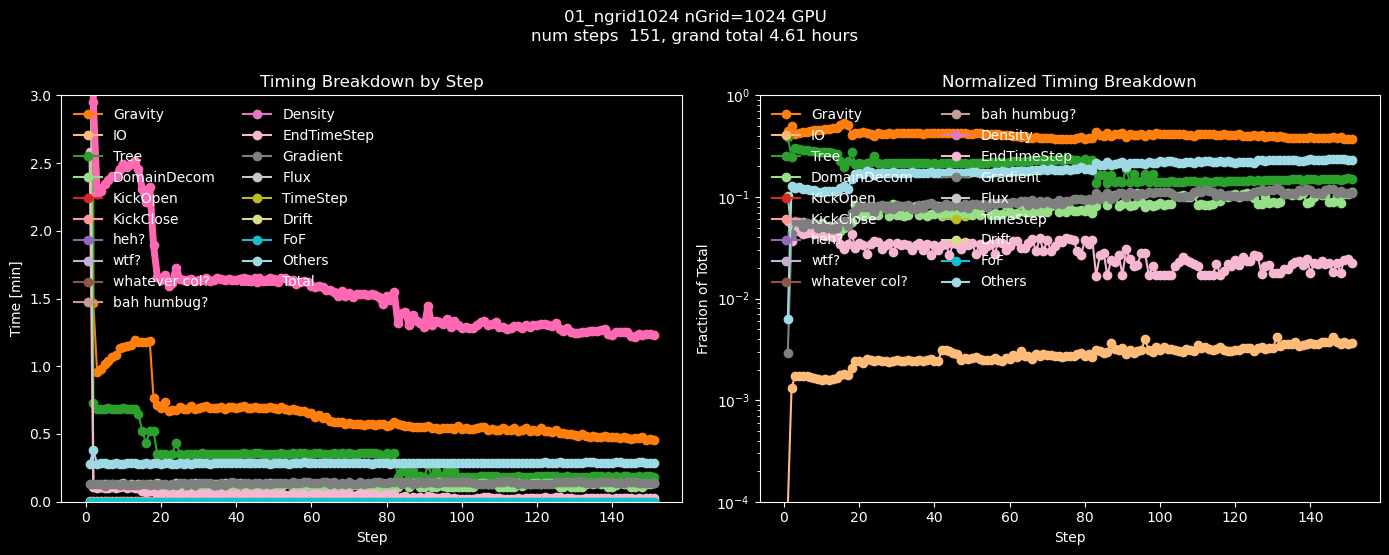

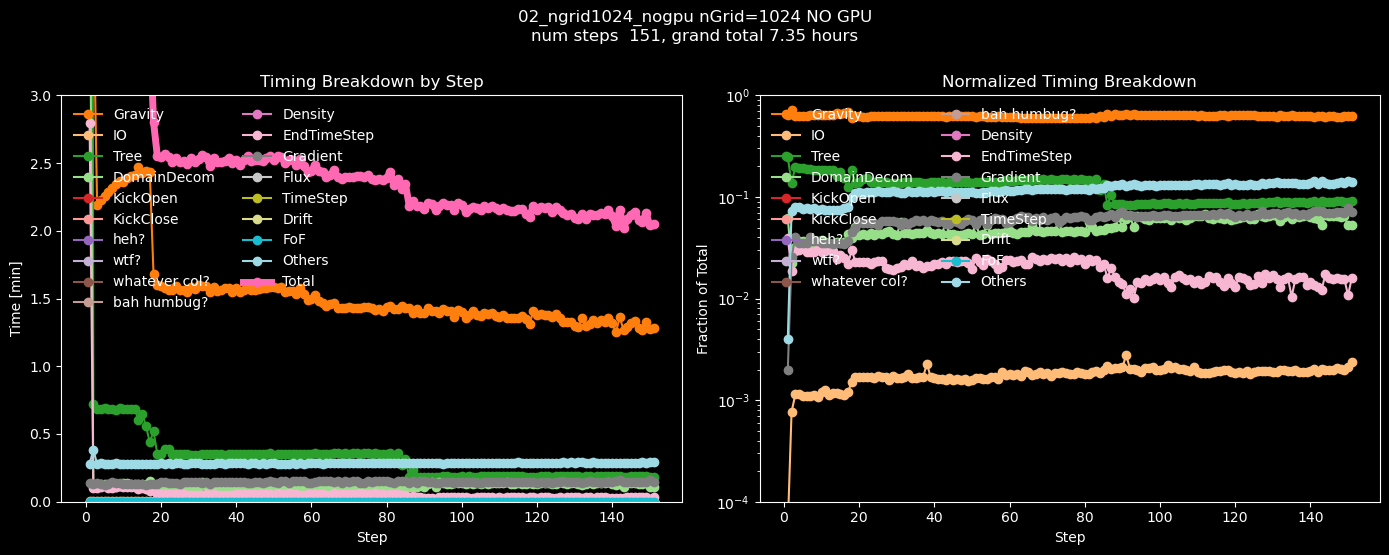

In [9]:
from jobstats import get_jobstats, print_summary
for case in ['01_ngrid1024', '02_ngrid1024_nogpu']:
    print(f'\nBENCHMARK: {case}\n')
    timings = load_timing(f'{case}/pkdgrav3_benchmark.timing')
    plot_timing(timings, title=case + ' ' + specs[case], ylim=(0, 3))
    stats = get_jobstats(case)
    print_summary(stats)
    

# Comapre cases

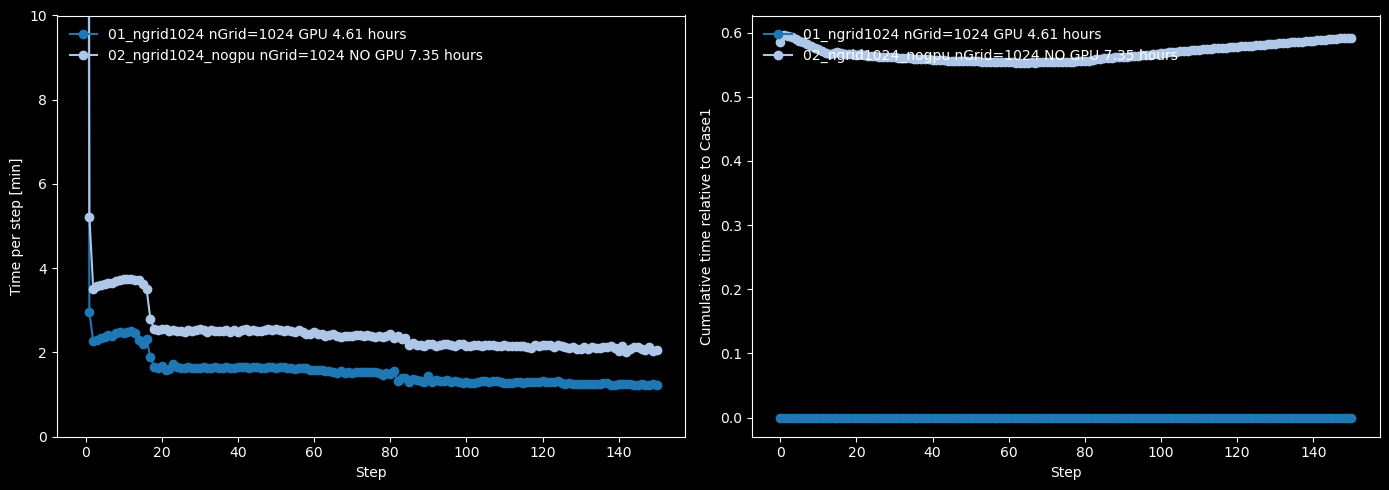

In [49]:
compare_cases(['01_ngrid1024', '02_ngrid1024_nogpu'], max_step=151, ylim=(0, 10))